## TSP

In [11]:
%pip install pulp pandas -q

import pulp
import pandas as pd
import math

# DADOS

# Coordenadas (para calcular distancias)
coords = {
    0: (0, 0),
    1: (3, 0),
    2: (5, 4),
    3: (2, 5),
    4: (6, 3) # 5 cidades
}
n = len(coords)
cidades = {0: "A", 1: "B", 2: "C", 3: "D", 4: "E"}

# Matriz de distancias (arredondada para int)
dist = [[0]*n for _ in range(n)]
for i in range(n):
  for j in range(n):
    if i != j:
      dx = coords[i][0] - coords[j][0]
      dy = coords[i][1] - coords[j][1]
      dist[i][j] = int(round(math.sqrt(dx*dx + dy*dy)))

# MODELO PLI (MTZ)

prob = pulp.LpProblem("TSP", pulp.LpMinimize)

# Variaveis x_ij binarias (se o arco i->j é usado)
x = [[pulp.LpVariable(f"x_{i}_{j}", cat='Binary') for j in range(n)] for i in range(n)]

# Variaveis u_i (ordem de visita, contínuas)
u = [pulp.LpVariable(f"u_{i}", lowBound=0, cat='Continuous') for i in range(n)]

# Restricao 1: cada cidade tem exatamente um sucessor
for i in range(n):
    prob += pulp.lpSum(x[i][j] for j in range(n) if j != i) == 1

# Restricao 2: cada cidade tem exatamente um predecessor
for j in range(n):
    prob += pulp.lpSum(x[i][j] for i in range(n) if i != j) == 1

# Restricao 3: eliminacao de sub-ciclos (MTZ)
for i in range(1, n):
    for j in range(1, n):
        if i != j:
            prob += u[i] - u[j] + n * x[i][j] <= n - 1

# Fixar u0 = 0 (opcional)
prob += u[0] == 0

# Funcao obj: min distancia total
prob += pulp.lpSum(dist[i][j] * x[i][j] for i in range(n) for j in range(n) if i != j)

prob.solve(pulp.PULP_CBC_CMD(msg=False))

# RESULTADOS (tabelas)
print("\nPROBLEMA DO CAIXEIRO VIAJANTE (TSP)\n")

# TABELA 1: MATRIZ DE CUSTOS
df_custos = pd.DataFrame(dist,
                        index=[cidades[i] for i in range(n)],
                        columns=[cidades[j] for j in range(n)])
print("\n-> MATRIZ DE DISTÂNCIAS ENTRE TODAS AS CIDADES\n")
display(df_custos)

print("\n-> SOLUÇÃO ÓTIMA\n")
print(f"Status: {pulp.LpStatus[prob.status]}")
print(f"Custo total mínimo: {pulp.value(prob.objective):.0f}\n")

# Reconstruindo a rota (iniciando pela cidade 0)
arestas = [(i, j) for i in range(n) for j in range(n) if i != j and x[i][j].varValue > 0.5]
ordem = [0]
atual = 0
while len(ordem) < n:
  for j in range(n):
    if (atual, j) in arestas:
      ordem.append(j)
      atual = j
      break
ordem.append(0)  # fecha o ciclo

# Tabela 2: Rota (ordem de visita)
df_rota = pd.DataFrame({
  'Posição': list(range(1, n+1)) + ['Retorno'],
  'Cidade': [cidades[i] for i in ordem]
})
print("-> ROTA ÓTIMA\n")
display(df_rota)

# Tabela 3: Arcos percorridos com distâncias e custo acumulado
dados = []
acum = 0
for k in range(len(ordem)-1):
  i, j = ordem[k], ordem[k+1]
  d = dist[i][j]
  acum += d
  dados.append({
    'Origem': cidades[i],
    'Destino': cidades[j],
        'Distância': d,
        'Custo Acumulado': acum
    })
df_arcos = pd.DataFrame(dados)
print("\n-> ARCOS PERCORRIDOS\n")
display(df_arcos)

Note: you may need to restart the kernel to use updated packages.

PROBLEMA DO CAIXEIRO VIAJANTE (TSP)


-> MATRIZ DE DISTÂNCIAS ENTRE TODAS AS CIDADES



,A,B,C,D,E
A,0,3,6,5,7
B,3,0,4,5,4
C,6,4,0,3,1
D,5,5,3,0,4
E,7,4,1,4,0



-> SOLUÇÃO ÓTIMA

Status: Optimal
Custo total mínimo: 16

-> ROTA ÓTIMA



,Posição,Cidade
0,1,A
1,2,D
2,3,C
3,4,E
4,5,B
5,Retorno,A



-> ARCOS PERCORRIDOS



,Origem,Destino,Distância,Custo Acumulado
0,A,D,5,5
1,D,C,3,8
2,C,E,1,9
3,E,B,4,13
4,B,A,3,16


Note: you may need to restart the kernel to use updated packages.


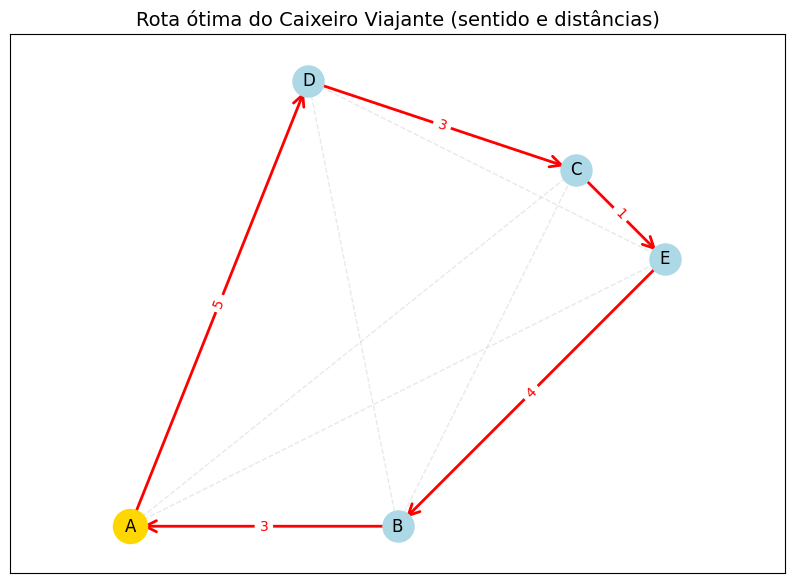

In [12]:
%pip install networkx matplotlib -q

import networkx as nx
import matplotlib.pyplot as plt

# Criar grafo direcionado para mostrar o sentido
G = nx.DiGraph()
for i in range(len(ordem)-1):
    G.add_edge(ordem[i], ordem[i+1], weight=dist[ordem[i]][ordem[i+1]])

pos = coords  # coord fixas

plt.figure(figsize=(10, 7))

# Desenhar todas as arestas possíveis - cinza claro
G_all = nx.complete_graph(len(coords))
nx.draw_networkx_edges(G_all, pos, edge_color='lightgray', width=1, alpha=0.5, style='dashed')

# Desenhar a rota ótima com setas (direcionadas)
nx.draw_networkx_edges(G, pos, edge_color='red', width=2, arrows=True, arrowsize=20, arrowstyle='->')

# Desenhar nós
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)
nx.draw_networkx_labels(G, pos, labels=cidades, font_size=12)

# Destacar cidade inicial
nx.draw_networkx_nodes(G, pos, nodelist=[ordem[0]], node_color='gold', node_size=600)

# Adicionar rótulos com os custos (distâncias) sobre cada aresta da rota
edge_labels = {(ordem[k], ordem[k+1]): str(dist[ordem[k]][ordem[k+1]]) for k in range(len(ordem)-1)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=10, label_pos=0.5)

plt.title("Rota ótima do Caixeiro Viajante (sentido e distâncias)", fontsize=14)
plt.axis('equal')
plt.show()